# Bruker / ScanImage structural volume alignment QC

This notebook runs the `slap2_volume_align` ScanImage alignment pipeline, then inspects the averaged output TIFF(s) and alignment diagnostics.

It is designed for large structural volume TIFFs where the file should be processed plane-by-plane rather than loaded into memory all at once. Your current reference stack appears to be organized as `slice_blocks`:

```text
z0 repeat0..19,
z1 repeat0..19,
z2 repeat0..19,
...
```

For the first full run, use a small plane range first, inspect the QC, then run the full stack.


## 1. Imports and repo setup

Run this notebook from either the repo root or the `notebooks/` directory. The cell below adds `src/` to `sys.path` so the package is importable before/without installation.


In [1]:

from __future__ import annotations

import json
import math
import os
import sys
import warnings
from pathlib import Path
from typing import Optional

from IPython.display import display, HTML

import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt


def find_repo_root(start: Optional[Path] = None) -> Path:
    """Find repo root from nested notebook directories."""
    if start is None:
        start = Path.cwd()
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "slap2_volume_align").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find repo root containing pyproject.toml and src/slap2_volume_align. "
        f"Started from: {start}"
    )


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from slap2_volume_align.readers.tiff import (
    read_tiff_stack_spec,
    read_plane_channel_frames,
)
from slap2_volume_align.sources.scanimage.metadata import parse_scanimage_description
from slap2_volume_align.core.registration import (
    estimate_rigid_shift,
    make_template,
    mean_shifted_frames,
)
from slap2_volume_align.sources.scanimage.pipeline import (
    ScanImageAverageConfig,
    average_scanimage_volume,
)
from slap2_volume_align.core.straightening import (
    straighten_volume_tiff,
    estimate_z_straightening_shifts,
    apply_z_straightening,
    write_straightening_csv,
    make_straightening_qc_png,
)
from slap2_volume_align.core.bidirectional import (
    apply_bidirectional_phase,
    estimate_bidirectional_phase_stack,
)

print(f"Repo root: {REPO_ROOT}")
print(f"Source dir: {SRC_DIR}")
print(f"Python: {sys.version}")

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")
print("Imports OK")


Repo root: C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\morphology\slap2-volume-alignment
Source dir: C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\morphology\slap2-volume-alignment\src
Python: 3.9.12 (main, Apr  4 2022, 05:22:27) [MSC v.1916 64 bit (AMD64)]


Imports OK


## 2. User parameters

Edit these paths and parameters for the session you want to process.

Notes:

- `N_PLANES=177`, `REPEATS_PER_PLANE=20`, `N_CHANNELS=1`, and `ORDER='slice_blocks'` match the first test stack.
- For future two-channel ScanImage stacks, use `N_CHANNELS=2` and keep `ALIGNMENT_CHANNEL=0` if green/channel 1 should drive alignment.
- `OUTPUT_DTYPE='float32'` is recommended because averaging and subpixel shifts produce non-integer values.


In [2]:
# --- Input/output paths ---
INPUT_TIF = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\836174\836174_2026-06-17_12-51-17\reference_volume\2026-06-17_836174_stack_00001.tif")
OUT_DIR = INPUT_TIF.parent / "aligned_volume"

# --- Stack layout ---
N_PLANES = 177
REPEATS_PER_PLANE = 20
N_CHANNELS = 1
ALIGNMENT_CHANNEL = 0  # zero-based; 0 == channel 1
ORDER = "slice_blocks"  # "slice_blocks" or "volume_interleaved"

# --- Processing range ---
# Start with a smoke test, e.g. 0:3. Then set PLANE_STOP = None for the full volume.
PLANE_START = 0
PLANE_STOP = None  # exclusive; set to None for full stack

# --- Registration parameters ---
ALIGN = True
REGISTRATION_BINNING = 4      # estimate shifts on downsampled images; shifts are applied full-res
UPSAMPLE_FACTOR = 10          # with binning=4 this gives ~0.4 px shift precision
MAX_SHIFT_PX = 12.0           # reject large/implausible shifts
REGISTRATION_N_PASSES = 2     # refine the template after an initial motion-corrected average
HIGHPASS_SIGMA_PX = 8.0       # broad background subtraction before registration
INTERPOLATION_ORDER = 1       # 1 = bilinear; 0 = nearest; 3 = cubic but slower
TEMPLATE_METHOD = "median"    # "median" or "mean"

# --- Output options ---
OUTPUT_DTYPE = "float32"
OUTPUT_COMPRESSION = None     # None is fastest for validation; use "zlib" later if desired
WRITE_QC_PNG = True

# --- Notebook diagnostics ---
DISPLAY_DOWNSAMPLE = 8        # display only; saved TIFF remains full resolution
SELECTED_Z_FOR_RAW_CHECK = 0
Z_PROFILE_STEP = 1            # use 1 for all output planes; increase for faster coarse QC

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(INPUT_TIF)
print(OUT_DIR)


# --- Optional bidirectional line-phase correction ---
# AUTO_ESTIMATE_BIDIPHASE samples raw frames, scores candidate phases, and then
# overwrites BIDIPHASE/BIDI_LINE_PARITY before the full averaging run.
AUTO_ESTIMATE_BIDIPHASE = True
BIDIPHASE = 4.0              # fallback/manual value when AUTO_ESTIMATE_BIDIPHASE=False
BIDI_LINE_PARITY = "auto"   # "auto", "odd", or "even"
BIDI_FILL_MODE = "nearest"  # avoid preserving uncorrected edge pixels
BIDI_SHIFT_MODE = "symmetric"  # resample both row parities; reduces residual sawtooth texture
BIDI_PHASE_CANDIDATES = np.arange(-8.0, 8.01, 0.25)
BIDI_SAMPLE_Z_INDICES = (25, 33, 41, 49)
BIDI_SAMPLE_REPEAT_INDICES = (0, 5, 10, 15)

# --- Optional second-pass z-stack straightening ---
# This corrects residual lateral jitter between averaged z-planes.
STRAIGHTEN_Z = True
Z_ANCHOR = None                 # auto-pick high-contrast plane; or set an integer z index
Z_TEMPLATE_RADIUS = 2
Z_REGISTRATION_BINNING = 4
Z_UPSAMPLE_FACTOR = 10
Z_MAX_STEP_SHIFT_PX = 12.0
Z_HIGHPASS_SIGMA_PX = 16.0
Z_SMOOTH_WINDOW = 15


\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\836174\836174_2026-06-17_12-51-17\reference_volume\2026-06-17_836174_stack_00001.tif
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\836174\836174_2026-06-17_12-51-17\reference_volume\aligned_volume


## 3. Inspect the source TIFF without loading it into memory

This confirms page count, shape, dtype, and a few ScanImage per-frame metadata fields.


In [3]:

with tifffile.TiffFile(INPUT_TIF) as tif:
    print(f"n_pages: {len(tif.pages)}")
    print(f"page[0].shape: {tif.pages[0].shape}")
    print(f"page[0].dtype: {tif.pages[0].dtype}")
    print("\nFirst page description excerpt:")
    print((tif.pages[0].description or "")[:2000])

    probe_pages = sorted(set([
        0, 1, REPEATS_PER_PLANE - 1, REPEATS_PER_PLANE,
        2 * REPEATS_PER_PLANE - 1, 2 * REPEATS_PER_PLANE,
        len(tif.pages) - 1,
    ]))
    rows = []
    for p in probe_pages:
        desc = parse_scanimage_description(tif.pages[p].description)
        rows.append({
            "page": p,
            "frame_number": desc.frame_number,
            "acquisition_number": desc.acquisition_number,
            "frame_number_acquisition": desc.frame_number_acquisition,
            "frame_timestamp_sec": desc.frame_timestamp_sec,
        })

pd.DataFrame(rows)


n_pages: 3540
page[0].shape: (2048, 2048)
page[0].dtype: int16

First page description excerpt:
frameNumbers = 1
acquisitionNumbers = 1
frameNumberAcquisition = 1
frameTimestamps_sec = 0.000000000
acqTriggerTimestamps_sec = -0.000106335
nextFileMarkerTimestamps_sec = -1.000000000
endOfAcquisition = 0
endOfAcquisitionMode = 0
dcOverVoltage = 0
epoch = [2026  6 18 14 48 46.513]
auxTrigger0 = []
auxTrigger1 = []
auxTrigger2 = []
auxTrigger3 = []
I2CData = {}


,page,frame_number,acquisition_number,frame_number_acquisition,frame_timestamp_sec
0,0,1,1,1,0.000000
1,1,2,1,2,0.130468
2,19,20,1,20,2.478981
3,20,21,2,1,2.880403
4,39,40,2,20,5.359571
5,40,41,3,1,5.736871
6,3539,3540,177,20,538.181674


## 4. Verify inferred layout

`read_tiff_stack_spec` checks that the requested layout accounts for every TIFF page. If `infer_from_descriptions=True`, it can also infer `n_planes` and `repeats_per_plane` from ScanImage fields like `acquisitionNumbers` and `frameNumberAcquisition`.


In [4]:

spec = read_tiff_stack_spec(
    INPUT_TIF,
    n_planes=N_PLANES,
    repeats_per_plane=REPEATS_PER_PLANE,
    n_channels=N_CHANNELS,
    order=ORDER,
    infer_from_descriptions=True,
)

spec.to_dict()


{'n_pages': 3540,
 'image_shape': [2048, 2048],
 'dtype': 'int16',
 'n_planes': 177,
 'repeats_per_plane': 20,
 'n_channels': 1,
 'order': 'slice_blocks'}

## 5. Raw page-order/contact-sheet QC

This plots raw repeats for selected z-planes directly from the input TIFF. Adjacent tiles should look like noisy/motion-shifted views of the same z-plane if `ORDER='slice_blocks'` is correct.


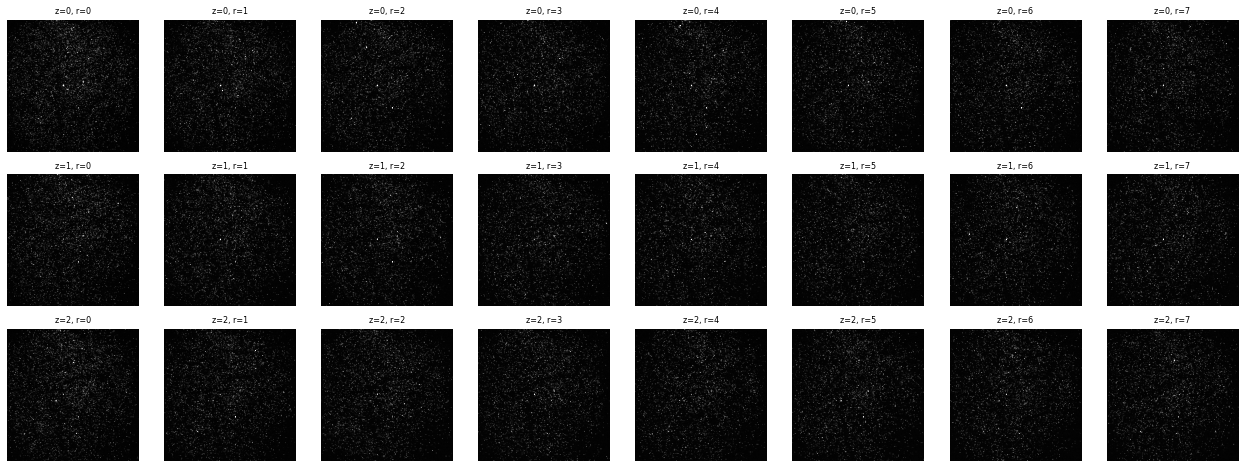

In [5]:

def robust_limits(img, pct=(1, 99.8)):
    finite = np.isfinite(img)
    if not finite.any():
        return 0, 1
    lo, hi = np.percentile(img[finite], pct)
    if hi <= lo:
        hi = lo + 1
    return lo, hi


def show_raw_repeats(
    input_tif: Path,
    z_indices=(0, 1, 2),
    channel_index=0,
    max_repeats=8,
    downsample=8,
):
    nrows = len(z_indices)
    ncols = min(max_repeats, spec.repeats_per_plane)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(2.2 * ncols, 2.2 * nrows), squeeze=False
    )

    with tifffile.TiffFile(input_tif) as tif:
        for row, z in enumerate(z_indices):
            frames = read_plane_channel_frames(
                tif, z_index=z, channel_index=channel_index, spec=spec
            )
            for col, frame in enumerate(frames[:ncols]):
                ax = axes[row, col]
                thumb = frame[::downsample, ::downsample]
                lo, hi = robust_limits(thumb)
                ax.imshow(thumb, cmap="gray", vmin=lo, vmax=hi)
                ax.set_title(f"z={z}, r={col}", fontsize=8)
                ax.axis("off")

    fig.tight_layout()
    return fig

fig = show_raw_repeats(INPUT_TIF, z_indices=range(PLANE_START, min(PLANE_START + 3, N_PLANES)), downsample=DISPLAY_DOWNSAMPLE)
plt.show()


## 6. Estimate bidirectional phase before alignment

This cell samples raw frames, chooses the alternating-line phase/parity, and sets the values used by the full averaging run. Run this before the motion-correction cell.


In [6]:
# Estimate bidirectional phase on raw frames before any motion correction.
# This should be done on a few representative z planes with visible puncta/processes.
if AUTO_ESTIMATE_BIDIPHASE:
    sample_frames = []
    sample_meta = []
    candidate_z = [z for z in BIDI_SAMPLE_Z_INDICES if 0 <= int(z) < spec.n_planes]
    candidate_repeats = [r for r in BIDI_SAMPLE_REPEAT_INDICES if 0 <= int(r) < spec.repeats_per_plane]

    with tifffile.TiffFile(INPUT_TIF) as tif:
        for z in candidate_z:
            frames = read_plane_channel_frames(
                tif,
                z_index=int(z),
                channel_index=ALIGNMENT_CHANNEL,
                spec=spec,
            )
            for r in candidate_repeats:
                sample_frames.append(frames[int(r)])
                sample_meta.append({"z_index": int(z), "repeat_index": int(r)})

    parity_candidates = ("odd", "even") if BIDI_LINE_PARITY == "auto" else (BIDI_LINE_PARITY,)
    bidi_estimate = estimate_bidirectional_phase_stack(
        sample_frames,
        phase_candidates=BIDI_PHASE_CANDIDATES,
        line_parity_candidates=parity_candidates,
        crop_yx=(128, 128),
        x_stride=1,
        highpass_sigma_px=8.0,
        shift_mode=BIDI_SHIFT_MODE,
    )

    BIDIPHASE = float(bidi_estimate["best_phase"])
    BIDI_LINE_PARITY = str(bidi_estimate["best_line_parity"])
    print(f"Estimated BIDIPHASE={BIDIPHASE:+.2f} px, BIDI_LINE_PARITY={BIDI_LINE_PARITY}")
    print(f"Median-score improvement over zero phase: {bidi_estimate['improvement_pct']:.2f}%")

    bidi_scores = pd.DataFrame(bidi_estimate["aggregate_scores"])
    display(
        bidi_scores.sort_values("median_score")
        .head(12)
        .reset_index(drop=True)
    )
else:
    print(f"Using manual BIDIPHASE={BIDIPHASE:+.2f} px, BIDI_LINE_PARITY={BIDI_LINE_PARITY}")


Estimated BIDIPHASE=-5.00 px, BIDI_LINE_PARITY=even
Median-score improvement over zero phase: 5.77%


,line_parity,phase,median_score,mean_score,n_frames
0,even,-5.00,1089.549988,1103.364578,16
1,odd,5.00,1089.789429,1103.845776,16
2,even,-5.25,1090.972412,1104.912979,16
3,odd,5.25,1091.259460,1105.379704,16
4,odd,3.25,1091.299561,1106.665287,16
5,even,-3.25,1091.418213,1106.267921,16
6,even,-4.75,1091.463196,1105.447540,16
7,odd,4.75,1091.683350,1105.934689,16
8,odd,3.00,1093.261597,1108.471012,16
9,odd,3.50,1093.318054,1109.017605,16


## 6. Run ScanImage alignment / averaging

For validation, keep `PLANE_STOP=3` first. Once the QC looks right, set `PLANE_STOP=None` and rerun for the full volume.


In [7]:

config = ScanImageAverageConfig(
    input_tif=INPUT_TIF,
    out_dir=OUT_DIR,
    n_planes=N_PLANES,
    repeats_per_plane=REPEATS_PER_PLANE,
    n_channels=N_CHANNELS,
    alignment_channel=ALIGNMENT_CHANNEL,
    order=ORDER,
    plane_start=PLANE_START,
    plane_stop=PLANE_STOP,
    template_method=TEMPLATE_METHOD,
    align=ALIGN,
    registration_binning=REGISTRATION_BINNING,
    upsample_factor=UPSAMPLE_FACTOR,
    max_shift_px=MAX_SHIFT_PX,
    highpass_sigma_px=HIGHPASS_SIGMA_PX,
    registration_n_passes=REGISTRATION_N_PASSES,
    interpolation_order=INTERPOLATION_ORDER,
    output_dtype=OUTPUT_DTYPE,
    output_compression=OUTPUT_COMPRESSION,
    write_qc_png=WRITE_QC_PNG,
    bidiphase=BIDIPHASE,
    bidi_line_parity=BIDI_LINE_PARITY,
    bidi_fill_mode=BIDI_FILL_MODE,
    bidi_shift_mode=BIDI_SHIFT_MODE,
    straighten_z=STRAIGHTEN_Z,
    z_anchor=Z_ANCHOR,
    z_template_radius=Z_TEMPLATE_RADIUS,
    z_registration_binning=Z_REGISTRATION_BINNING,
    z_upsample_factor=Z_UPSAMPLE_FACTOR,
    z_max_step_shift_px=Z_MAX_STEP_SHIFT_PX,
    z_highpass_sigma_px=Z_HIGHPASS_SIGMA_PX,
    z_smooth_window=Z_SMOOTH_WINDOW,
)

summary = average_scanimage_volume(config)
summary


Processing z 0 (1/177)
Processing z 1 (2/177)
Processing z 2 (3/177)
Processing z 3 (4/177)
Processing z 4 (5/177)
Processing z 5 (6/177)
Processing z 6 (7/177)
Processing z 7 (8/177)
Processing z 8 (9/177)
Processing z 9 (10/177)
Processing z 10 (11/177)
Processing z 11 (12/177)
Processing z 12 (13/177)
Processing z 13 (14/177)
Processing z 14 (15/177)
Processing z 15 (16/177)
Processing z 16 (17/177)
Processing z 17 (18/177)
Processing z 18 (19/177)
Processing z 19 (20/177)
Processing z 20 (21/177)
Processing z 21 (22/177)
Processing z 22 (23/177)
Processing z 23 (24/177)
Processing z 24 (25/177)
Processing z 25 (26/177)
Processing z 26 (27/177)
Processing z 27 (28/177)
Processing z 28 (29/177)
Processing z 29 (30/177)
Processing z 30 (31/177)
Processing z 31 (32/177)
Processing z 32 (33/177)
Processing z 33 (34/177)
Processing z 34 (35/177)
Processing z 35 (36/177)
Processing z 36 (37/177)
Processing z 37 (38/177)
Processing z 38 (39/177)
Processing z 39 (40/177)
Processing z 40 (41

{'config': {'input_tif': '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\836174\\836174_2026-06-17_12-51-17\\reference_volume\\2026-06-17_836174_stack_00001.tif',
  'out_dir': '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\836174\\836174_2026-06-17_12-51-17\\reference_volume\\aligned_volume',
  'n_planes': 177,
  'repeats_per_plane': 20,
  'n_channels': 1,
  'alignment_channel': 0,
  'order': 'slice_blocks',
  'plane_start': 0,
  'plane_stop': None,
  'template_method': 'median',
  'align': True,
  'registration_binning': 4,
  'upsample_factor': 10,
  'max_shift_px': 12.0,
  'highpass_sigma_px': 8.0,
  'interpolation_order': 1,
  'output_dtype': 'float32',
  'output_compression': None,
  'infer_from_descriptions': True,
  'write_qc_png': True,
  'bidiphase': -5.0,
  'bidi_line_parity': 'even',
  'bidi_fill_mode': 'nearest',
  'bidi_shift_mode': 'symmetric',
  'registration_n_passes': 2,
  'straighten_z': True,
  '

## 7. Load summary and shift table

The shift table is one row per `z × repeat`, estimated on the alignment channel and applied to all channels.


In [8]:

summary_path = Path(summary["summary_json"])
shifts_path = Path(summary["shifts_csv"])

with summary_path.open("r") as f:
    summary_loaded = json.load(f)

shift_df = pd.read_csv(shifts_path)
shift_df["shift_magnitude_px"] = np.sqrt(shift_df["shift_y_px"] ** 2 + shift_df["shift_x_px"] ** 2)

print(f"Summary JSON: {summary_path}")
print(f"Shift CSV: {shifts_path}")
print(f"Rows: {len(shift_df)}")
shift_df.head()


Summary JSON: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\836174\836174_2026-06-17_12-51-17\reference_volume\aligned_volume\2026-06-17_836174_stack_00001_alignment_summary.json
Shift CSV: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\836174\836174_2026-06-17_12-51-17\reference_volume\aligned_volume\2026-06-17_836174_stack_00001_alignment_shifts.csv
Rows: 3540


,z_index,repeat_index,alignment_channel,shift_y_px,shift_x_px,accepted,error,phase_difference,reason,shift_magnitude_px
0,0,0,0,0.0,-0.4,True,1.0,0.000592,NaN,0.4
1,0,1,0,0.0,-0.4,True,1.0,0.000424,NaN,0.4
2,0,2,0,0.0,-0.4,True,1.0,0.000347,NaN,0.4
3,0,3,0,0.0,-0.4,True,1.0,0.000379,NaN,0.4
4,0,4,0,0.0,-0.4,True,1.0,0.000330,NaN,0.4


## 8. Shift diagnostics

For a well-behaved structural stack, shifts should usually be small and smoothly distributed. A large number of rejected frames or a heavy-tailed shift distribution suggests the registration settings or stack layout need review.


In [9]:

display(shift_df.groupby("z_index").agg(
    n=("repeat_index", "count"),
    accepted_frac=("accepted", "mean"),
    median_shift_y_px=("shift_y_px", "median"),
    median_shift_x_px=("shift_x_px", "median"),
    max_shift_magnitude_px=("shift_magnitude_px", "max"),
    mean_error=("error", "mean"),
))

rejected = shift_df.loc[~shift_df["accepted"].astype(bool)]
if len(rejected):
    print("Rejected frames:")
    display(rejected)
else:
    print("No rejected frames.")


,n,accepted_frac,median_shift_y_px,median_shift_x_px,max_shift_magnitude_px,mean_error
z_index,,,,,,
0,20,1.0,0.0,0.0,0.4,1.0
1,20,1.0,0.0,0.0,0.0,1.0
2,20,1.0,0.0,0.0,0.0,1.0
3,20,1.0,0.0,0.0,0.0,1.0
4,20,1.0,0.0,0.0,0.4,1.0
...,...,...,...,...,...,...
172,20,1.0,0.0,0.0,0.4,1.0
173,20,1.0,0.0,0.0,0.4,1.0
174,20,1.0,0.0,0.0,0.4,1.0


No rejected frames.


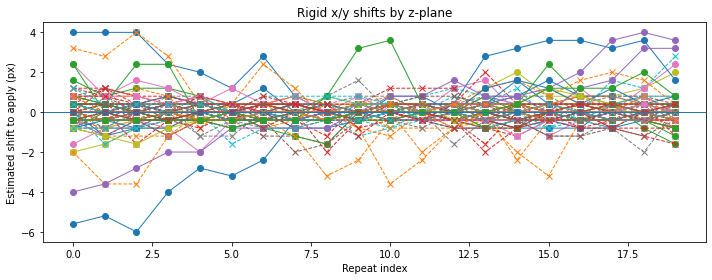

In [10]:

def plot_shift_traces(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(10, 4))
    for z, g in df.groupby("z_index"):
        ax.plot(g["repeat_index"], g["shift_y_px"], marker="o", linewidth=1, label=f"z {z} y")
        ax.plot(g["repeat_index"], g["shift_x_px"], marker="x", linewidth=1, linestyle="--", label=f"z {z} x")
    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Repeat index")
    ax.set_ylabel("Estimated shift to apply (px)")
    ax.set_title("Rigid x/y shifts by z-plane")
#     ax.legend(ncol=2, fontsize=8, frameon=False)
    fig.tight_layout()
    return fig

fig = plot_shift_traces(shift_df)
plt.show()


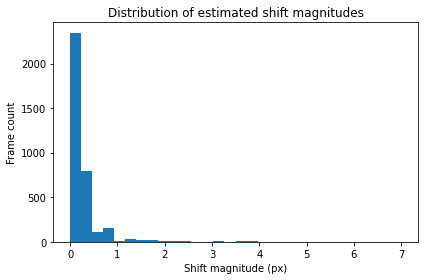

In [11]:

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(shift_df["shift_magnitude_px"].dropna(), bins=30)
ax.set_xlabel("Shift magnitude (px)")
ax.set_ylabel("Frame count")
ax.set_title("Distribution of estimated shift magnitudes")
fig.tight_layout()
plt.show()


## 9. Inspect output TIFF(s) lazily

This reads only selected planes from the averaged output TIFF, not the whole volume.


In [12]:

output_paths = {k: Path(v) for k, v in summary_loaded["outputs"].items()}
output_paths


{'channel_1': WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/iGluSnFR4f+RCaMP3/836174/836174_2026-06-17_12-51-17/reference_volume/aligned_volume/2026-06-17_836174_stack_00001_avg_ch1.tif')}

### Optional z-straightening outputs

If `STRAIGHTEN_Z=True`, inspect the straightened outputs and z-shift CSV here. You can also run `straighten_volume_tiff()` posthoc on an existing averaged volume.

In [13]:

straightened_output_paths = {k: Path(v) for k, v in summary_loaded.get("straightened_outputs", {}).items() if v}
z_straightening_csv = summary_loaded.get("z_straightening_csv")

print("Straightened outputs:")
display(straightened_output_paths)
print("Z-straightening CSV:", z_straightening_csv)

if z_straightening_csv:
    z_shift_df = pd.read_csv(z_straightening_csv)
    z_shift_df["smooth_shift_magnitude_px"] = np.sqrt(
        z_shift_df["smooth_shift_y_px"] ** 2 + z_shift_df["smooth_shift_x_px"] ** 2
    )
    display(z_shift_df.head())
else:
    z_shift_df = None


Straightened outputs:


{'channel_1': WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/iGluSnFR4f+RCaMP3/836174/836174_2026-06-17_12-51-17/reference_volume/aligned_volume/2026-06-17_836174_stack_00001_avg_ch1_straightened.tif')}

Z-straightening CSV: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\836174\836174_2026-06-17_12-51-17\reference_volume\aligned_volume\2026-06-17_836174_stack_00001_z_straightening_shifts.csv


,volume_index,z_index,anchor_volume_index,anchor_z_index,raw_shift_y_px,raw_shift_x_px,smooth_shift_y_px,smooth_shift_x_px,accepted,error,phase_difference,reason,smooth_shift_magnitude_px
0,0,0,57,57,-8.4,0.0,-8.134117,-0.140000,True,1.0,0.000558,NaN,8.135322
1,1,1,57,57,-8.4,0.0,-8.319495,-0.117143,True,1.0,0.000343,NaN,8.320320
2,2,2,57,57,-8.4,-0.4,-8.459431,-0.101978,True,1.0,0.000772,NaN,8.460045
3,3,3,57,57,-8.4,0.0,-8.553923,-0.094505,True,1.0,0.000262,NaN,8.554445
4,4,4,57,57,-8.4,0.0,-8.602973,-0.094725,True,1.0,0.000301,NaN,8.603495


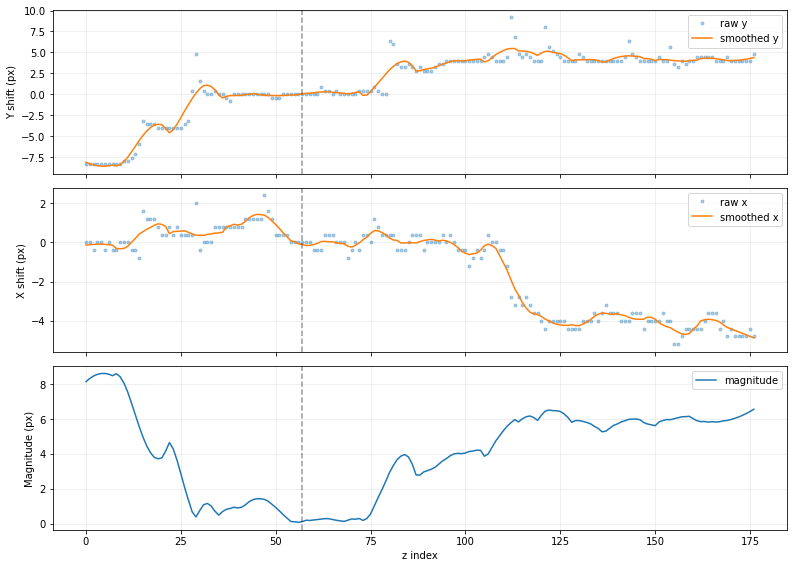

In [14]:

if z_shift_df is not None:
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
    axes[0].plot(z_shift_df["z_index"], z_shift_df["raw_shift_y_px"], ".", alpha=0.35, label="raw y")
    axes[0].plot(z_shift_df["z_index"], z_shift_df["smooth_shift_y_px"], "-", label="smoothed y")
    axes[0].set_ylabel("Y shift (px)")
    axes[0].legend()

    axes[1].plot(z_shift_df["z_index"], z_shift_df["raw_shift_x_px"], ".", alpha=0.35, label="raw x")
    axes[1].plot(z_shift_df["z_index"], z_shift_df["smooth_shift_x_px"], "-", label="smoothed x")
    axes[1].set_ylabel("X shift (px)")
    axes[1].legend()

    axes[2].plot(z_shift_df["z_index"], z_shift_df["smooth_shift_magnitude_px"], "-", label="magnitude")
    axes[2].set_ylabel("Magnitude (px)")
    axes[2].set_xlabel("z index")
    axes[2].legend()

    anchor = int(z_shift_df["anchor_z_index"].iloc[0])
    for ax in axes:
        ax.axvline(anchor, color="k", linestyle="--", alpha=0.4)
        ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()
else:
    print("No z-straightening CSV available. Set STRAIGHTEN_Z=True or run the posthoc cell below.")


### Posthoc z-straightening of an existing averaged TIFF

Use this if you already produced `*_avg_ch1.tif` and want to create `*_straightened.tif` without rerunning repeat-level averaging.

In [15]:

POSTHOC_STRAIGHTEN = True

if POSTHOC_STRAIGHTEN:
    output_ch_key = f"channel_{ALIGNMENT_CHANNEL + 1}"
    avg_tif = output_paths[output_ch_key]
    posthoc_out = avg_tif.with_name(f"{avg_tif.stem}_straightened.tif")
    posthoc_summary = straighten_volume_tiff(
        avg_tif,
        posthoc_out,
        anchor_z=Z_ANCHOR,
        template_radius=Z_TEMPLATE_RADIUS,
        binning=Z_REGISTRATION_BINNING,
        upsample_factor=Z_UPSAMPLE_FACTOR,
        max_step_shift_px=Z_MAX_STEP_SHIFT_PX,
        highpass_sigma_px=Z_HIGHPASS_SIGMA_PX,
        smooth_window=Z_SMOOTH_WINDOW,
        output_dtype=OUTPUT_DTYPE,
        output_compression=OUTPUT_COMPRESSION,
    )
    display(posthoc_summary)
else:
    print("Set POSTHOC_STRAIGHTEN=True to straighten an existing averaged TIFF.")


{'input_tif': '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\836174\\836174_2026-06-17_12-51-17\\reference_volume\\aligned_volume\\2026-06-17_836174_stack_00001_avg_ch1.tif',
 'output_tif': '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\836174\\836174_2026-06-17_12-51-17\\reference_volume\\aligned_volume\\2026-06-17_836174_stack_00001_avg_ch1_straightened.tif',
 'shift_source': 'estimated',
 'shifts_csv': '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\836174\\836174_2026-06-17_12-51-17\\reference_volume\\aligned_volume\\2026-06-17_836174_stack_00001_avg_ch1_z_straightening_shifts.csv',
 'qc_png': '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\836174\\836174_2026-06-17_12-51-17\\reference_volume\\aligned_volume\\2026-06-17_836174_stack_00001_avg_ch1_z_straightening_qc.png',
 'config': {'anchor_z': None,
  'template_radius': 2,
  'binning': 4

In [16]:

def inspect_tiff(path: Path):
    with tifffile.TiffFile(path) as tif:
        print(path)
        print(f"n_pages: {len(tif.pages)}")
        print(f"series count: {len(tif.series)}")
        for i, s in enumerate(tif.series):
            print(f"  series {i}: shape={s.shape}, dtype={s.dtype}, axes={s.axes}")
        print(f"page[0].shape: {tif.pages[0].shape}")
        print(f"page[0].dtype: {tif.pages[0].dtype}")
        desc = tif.pages[0].description or ""
        print("description excerpt:")
        print(desc[:500])

for path in output_paths.values():
    inspect_tiff(path)


\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\836174\836174_2026-06-17_12-51-17\reference_volume\aligned_volume\2026-06-17_836174_stack_00001_avg_ch1.tif
n_pages: 177
series count: 1
  series 0: shape=(177, 2048, 2048), dtype=float32, axes=ZYX
page[0].shape: (2048, 2048)
page[0].dtype: float32
description excerpt:
Averaged ScanImage volume from 2026-06-17_836174_stack_00001.tif; channel=1; axes=ZYX


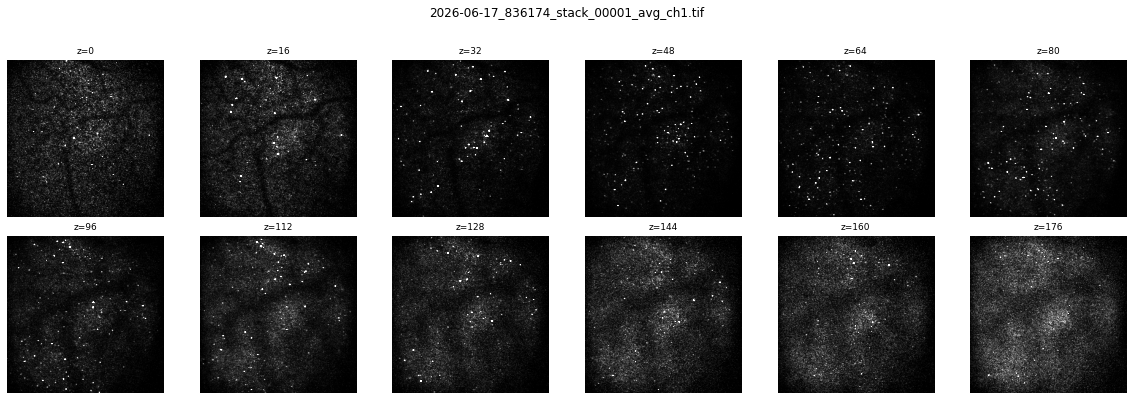

In [17]:

def read_output_planes(path: Path, z_indices, downsample: int = 1) -> dict[int, np.ndarray]:
    """Read selected z-planes from a ZYX output TIFF."""
    out = {}
    with tifffile.TiffFile(path) as tif:
        for z in z_indices:
            img = tif.pages[int(z)].asarray()
            if downsample > 1:
                img = img[::downsample, ::downsample]
            out[int(z)] = img
    return out


def show_output_montage(path: Path, z_indices=None, downsample=8):
    with tifffile.TiffFile(path) as tif:
        n_pages = len(tif.pages)
    if z_indices is None:
        z_indices = np.linspace(0, n_pages - 1, min(12, n_pages), dtype=int)

    planes = read_output_planes(path, z_indices, downsample=downsample)
    n = len(planes)
    ncols = min(6, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.7 * ncols, 2.7 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax, (z, img) in zip(axes, planes.items()):
        lo, hi = robust_limits(img)
        ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)
        ax.set_title(f"z={z}", fontsize=9)
        ax.axis("off")

    for ax in axes[len(planes):]:
        ax.axis("off")

    fig.suptitle(path.name, y=1.02)
    fig.tight_layout()
    return fig

for label, path in output_paths.items():
    fig = show_output_montage(path, downsample=DISPLAY_DOWNSAMPLE)
    plt.show()


## 10. Output intensity / focus diagnostics across z

This scans the output TIFF plane-by-plane and computes simple summary metrics. For the full 2048 × 2048 × 177 output, this reads the averaged output volume from disk once, but still does not load it all into memory simultaneously.


In [18]:

def compute_output_z_metrics(path: Path, step: int = 1, downsample: int = 4) -> pd.DataFrame:
    rows = []
    with tifffile.TiffFile(path) as tif:
        for z in range(0, len(tif.pages), step):
            img = tif.pages[z].asarray()
            if downsample > 1:
                img = img[::downsample, ::downsample]
            finite = np.isfinite(img)
            if finite.any():
                vals = img[finite]
                rows.append({
                    "z_index": z,
                    "mean": float(np.mean(vals)),
                    "median": float(np.median(vals)),
                    "std": float(np.std(vals)),
                    "p99": float(np.percentile(vals, 99)),
                    "p99_8": float(np.percentile(vals, 99.8)),
                    "finite_fraction": float(finite.mean()),
                })
            else:
                rows.append({
                    "z_index": z,
                    "mean": np.nan,
                    "median": np.nan,
                    "std": np.nan,
                    "p99": np.nan,
                    "p99_8": np.nan,
                    "finite_fraction": 0.0,
                })
    return pd.DataFrame(rows)

metrics_by_channel = {}
for label, path in output_paths.items():
    metrics_by_channel[label] = compute_output_z_metrics(
        path, step=Z_PROFILE_STEP, downsample=DISPLAY_DOWNSAMPLE
    )
    print(label, path)
    display(metrics_by_channel[label].head())


channel_1 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\836174\836174_2026-06-17_12-51-17\reference_volume\aligned_volume\2026-06-17_836174_stack_00001_avg_ch1.tif


,z_index,mean,median,std,p99,p99_8,finite_fraction
0,0,116.873390,68.000000,165.122726,685.365512,1174.476089,1.0
1,1,113.501862,65.000000,155.833771,653.109991,1143.097953,1.0
2,2,112.587173,63.299999,160.611511,670.914999,1182.255477,1.0
3,3,117.604149,67.550003,167.975189,694.997501,1203.921958,1.0
4,4,123.428307,73.080002,176.909180,692.035016,1201.485720,1.0


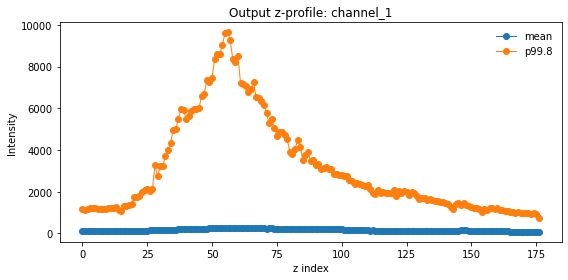

In [19]:

for label, metrics in metrics_by_channel.items():
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(metrics["z_index"], metrics["mean"], marker="o", linewidth=1, label="mean")
    ax.plot(metrics["z_index"], metrics["p99_8"], marker="o", linewidth=1, label="p99.8")
    ax.set_xlabel("z index")
    ax.set_ylabel("Intensity")
    ax.set_title(f"Output z-profile: {label}")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()


## 11. Raw repeat average versus aligned average for one z-plane

This is a useful local check. It reads all raw repeats for one selected z-plane, computes an unregistered mean, then compares it to the saved registered average.


In [20]:

raw_z = SELECTED_Z_FOR_RAW_CHECK
output_ch_key = f"channel_{ALIGNMENT_CHANNEL + 1}"
output_path = output_paths[output_ch_key]

with tifffile.TiffFile(INPUT_TIF) as raw_tif:
    raw_frames = read_plane_channel_frames(
        raw_tif, z_index=raw_z, channel_index=ALIGNMENT_CHANNEL, spec=spec
    )

raw_mean = np.mean(np.stack([f.astype(np.float32, copy=False) for f in raw_frames], axis=0), axis=0)

# Recompute shifts for this plane using current notebook settings, then compute an aligned mean.
template = make_template(raw_frames, method=TEMPLATE_METHOD)
recomputed_shifts = []
for frame in raw_frames:
    result = estimate_rigid_shift(
        template,
        frame,
        upsample_factor=UPSAMPLE_FACTOR,
        max_shift_px=MAX_SHIFT_PX,
        binning=REGISTRATION_BINNING,
        highpass_sigma_px=HIGHPASS_SIGMA_PX,
    )
    recomputed_shifts.append(result.shift_yx if result.accepted else (0.0, 0.0))

aligned_mean_recomputed = mean_shifted_frames(
    raw_frames,
    recomputed_shifts,
    order=INTERPOLATION_ORDER,
)

with tifffile.TiffFile(output_path) as out_tif:
    saved_aligned_mean = out_tif.pages[raw_z - PLANE_START].asarray()

print("Recomputed shifts:")
print(pd.DataFrame(recomputed_shifts, columns=["shift_y_px", "shift_x_px"]).describe())


Recomputed shifts:
       shift_y_px  shift_x_px
count        20.0   20.000000
mean          0.0    0.000000
std           0.0    0.129777
min           0.0   -0.400000
25%           0.0    0.000000
50%           0.0    0.000000
75%           0.0    0.000000
max           0.0    0.400000


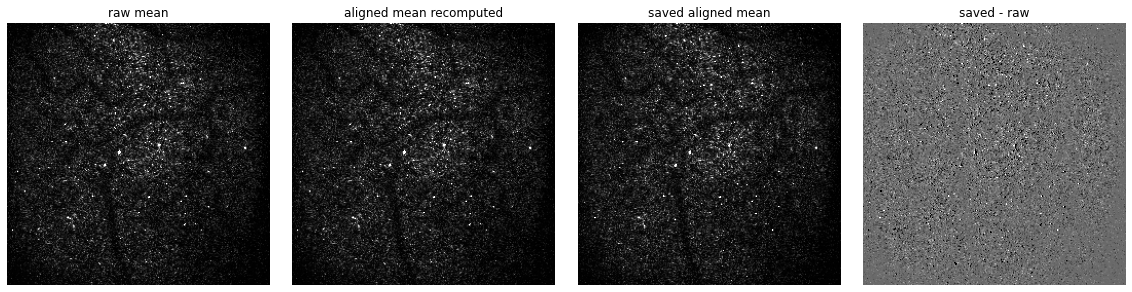

Max abs difference between saved and recomputed aligned mean: 11327.251


In [21]:

def show_comparison_images(images: dict[str, np.ndarray], downsample=8):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), squeeze=False)
    axes = axes.ravel()
    for ax, (title, img) in zip(axes, images.items()):
        thumb = img[::downsample, ::downsample]
        lo, hi = robust_limits(thumb)
        ax.imshow(thumb, cmap="gray", vmin=lo, vmax=hi)
        ax.set_title(title)
        ax.axis("off")
    fig.tight_layout()
    return fig

fig = show_comparison_images(
    {
        "raw mean": raw_mean,
        "aligned mean recomputed": aligned_mean_recomputed,
        "saved aligned mean": saved_aligned_mean,
        "saved - raw": saved_aligned_mean - raw_mean,
    },
    downsample=DISPLAY_DOWNSAMPLE,
)
plt.show()

print("Max abs difference between saved and recomputed aligned mean:", np.nanmax(np.abs(saved_aligned_mean - aligned_mean_recomputed)))


## 12. Save notebook-generated diagnostic figures/tables

This writes a compact diagnostics folder next to the averaged TIFF output.


In [22]:

DIAG_DIR = OUT_DIR / "notebook_diagnostics"
DIAG_DIR.mkdir(parents=True, exist_ok=True)

# Save shifts with magnitude added.
shift_df.to_csv(DIAG_DIR / "alignment_shifts_with_magnitude.csv", index=False)

# Save z metrics.
for label, metrics in metrics_by_channel.items():
    metrics.to_csv(DIAG_DIR / f"{label}_z_metrics.csv", index=False)

# Save a quick shift diagnostic plot.
fig = plot_shift_traces(shift_df)
fig.savefig(DIAG_DIR / "shift_traces.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Save output montage(s).
for label, path in output_paths.items():
    fig = show_output_montage(path, downsample=DISPLAY_DOWNSAMPLE)
    fig.savefig(DIAG_DIR / f"{label}_output_montage.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

print(f"Wrote diagnostics to: {DIAG_DIR}")


Wrote diagnostics to: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\836174\836174_2026-06-17_12-51-17\reference_volume\aligned_volume\notebook_diagnostics


## 13. Optional: open the averaged volume in napari

This is optional and intended for local interactive QC. It will try to load the full averaged TIFF into memory, so only use it when the output size is manageable on your workstation.


In [ ]:

# OPEN_NAPARI = False

# if OPEN_NAPARI:
#     import napari
#     viewer = napari.Viewer()
#     for label, path in output_paths.items():
#         data = tifffile.imread(path)
#         viewer.add_image(data, name=label, scale=(1, 1, 1))
#     napari.run()
# else:
#     print("Set OPEN_NAPARI=True to launch napari locally.")


## 14. Full-run checklist

Before processing the full 177-plane stack:

1. Confirm the raw contact sheet shows repeated views within each z-plane.
2. Confirm `read_tiff_stack_spec` accounts for all pages.
3. Run `PLANE_START=0`, `PLANE_STOP=3` and inspect:
   - output montage
   - shift magnitudes
   - rejected frames
   - raw mean versus aligned mean
4. Then set `PLANE_STOP=None` and rerun.
5. If shifts are nearly all zero, that is acceptable; the code still verifies each plane and applies the same transformation to future channels.
6. If many frames are rejected, first check `ORDER`, `N_CHANNELS`, and `REPEATS_PER_PLANE`; then tune `REGISTRATION_BINNING`, `HIGHPASS_SIGMA_PX`, and `MAX_SHIFT_PX`.
